In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from cs_priors.simulation.mixing_model import quick_sim
from cs_priors.solvers.freq_lasso import frequency_lasso_solve
from cs_priors.solvers.freq_group_lasso import frequency_group_lasso_solve
from cs_priors.solvers.freq_sparse_prior import sparse_prior_solve
from cs_priors.plotting.plot_complex import plot_matrices
from cs_priors.metrics.benchmark import grid_benchmark

# # groupyr is not compatible with sklearn 1.6, this is a workaround
# import sklearn.base as sklearn_base
# from sklearn.utils._tags import TransformerTags

# def _safe_transformer_tags(self):
#     tags = sklearn_base.BaseEstimator.__sklearn_tags__(self)
#     tags.transformer_tags = TransformerTags()
#     return tags

# sklearn_base.TransformerMixin.__sklearn_tags__ = _safe_transformer_tags

from cs_priors.solvers.freq_sparse_group_lasso import frequency_sparse_group_lasso_solve

# Recovery from noisy measurements using Moore-Penrose pseudoinverse

In [ ]:
params = {
    "num_mics": 10,
    "num_sources": 10,
    "num_active": 2,
    "seed": 0,
    "mode": "sine",
    "min_freq_hz": 1.0,
    "sensor_snr_db": 150,
    "inverse_method": "ridge",
    "amplitude": 10.0,
}

F = None
sim = quick_sim(**params)
keep = np.flatnonzero(sim.freqs > 0)[:F]

sim.A = sim.A[:, :, keep]
sim.Y = sim.Y[:, keep]
sim.X = sim.X[:, keep]
sim.X_pinv = sim.X_pinv[:, keep]
sim.freqs = sim.freqs[keep]

X_lasso = frequency_lasso_solve(sim.Y, sim.A)
X_group_lasso = frequency_group_lasso_solve(sim.Y, sim.A, grouping="frequency")
X_sparse_group_lasso = frequency_sparse_group_lasso_solve(sim.Y, sim.A, grouping="frequency")
X_sparse_prior = sparse_prior_solve(sim.X_pinv, sim.A, grouping="frequency")


plot_matrices([sim.X, sim.X_pinv, X_lasso, X_group_lasso, X_sparse_group_lasso, X_sparse_prior], titles=["True solution X", "Pseudoinverse solution", "Lasso solution", "Group Lasso solution", "Sparse Group Lasso solution", "Sparse Prior solution"])


# Ridge pseudoinverse

In [ ]:
params["inverse_method"] = "ridge"

sim = quick_sim(**params)
keep = np.flatnonzero(sim.freqs > 0)[:F]

sim.A = sim.A[:, :, keep]
sim.Y = sim.Y[:, keep]
sim.X = sim.X[:, keep]
sim.X_pinv = sim.X_pinv[:, keep]
sim.freqs = sim.freqs[keep]

X_lasso = frequency_lasso_solve(sim.Y, sim.A)
X_group_lasso = frequency_group_lasso_solve(sim.Y, sim.A, grouping="frequency")
X_sparse_group_lasso = frequency_sparse_group_lasso_solve(sim.Y, sim.A, alpha=1e-5, max_iter=20000, grouping="frequency")
X_sparse_prior = sparse_prior_solve(sim.X_pinv, sim.A, grouping="frequency") 

plot_matrices([sim.X, sim.X_pinv, X_lasso, X_group_lasso, X_sparse_group_lasso, X_sparse_prior], titles=["True solution X", "Pseudoinverse solution", "Lasso solution", "Group Lasso solution", "Sparse Group Lasso solution", "Sparse Prior solution"])

# Plot comparing sparse recovery vs noise
20 seeds, 95% confidence interval. runtime: 4m 14.7s



With Moore-Penrose:

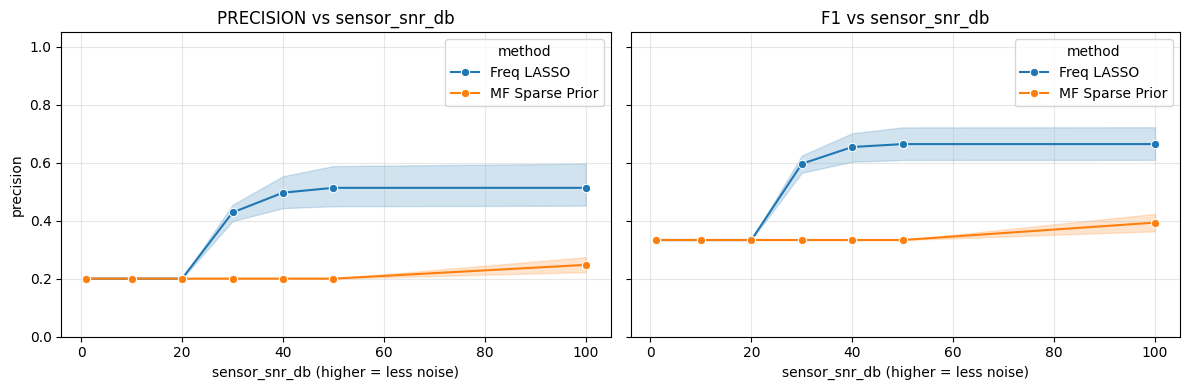

With Ridge, clearly odd that SP decreases

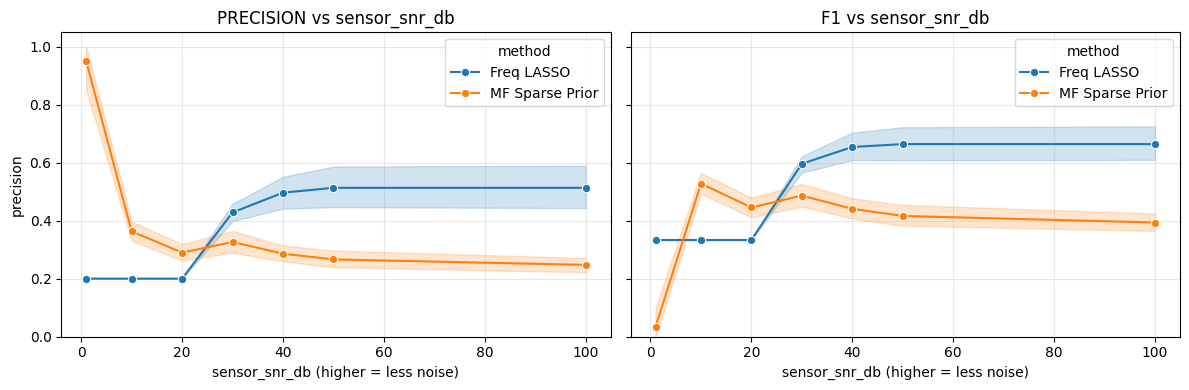

With initilization of SP at $X_{true}$, it succeds no matter the noise.

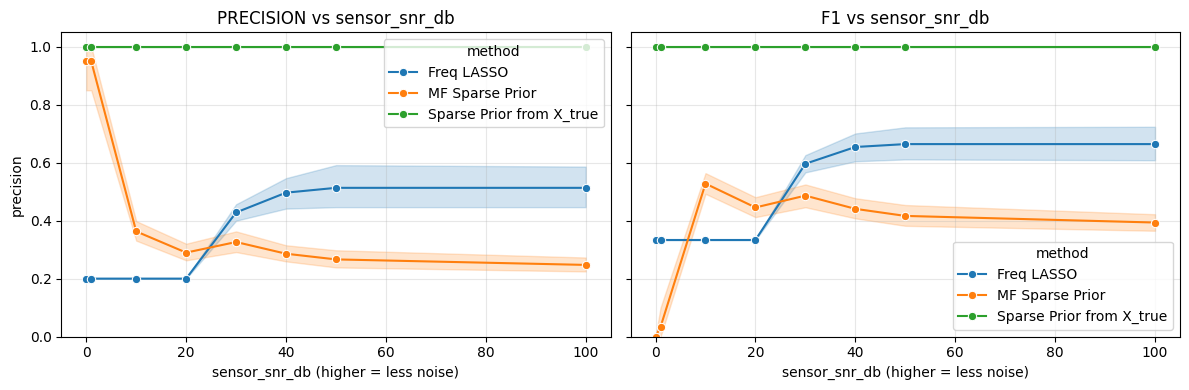

In [ ]:

# Three methods to compare
methods = {
    "Freq LASSO": lambda sim: frequency_lasso_solve(
        sim.Y,
        sim.A,
        alpha=1e-4,
        max_iter=10000,
    ),
    # "Freq Group LASSO": lambda sim: frequency_group_lasso_solve(
    #     sim.Y,
    #     sim.A,
    #     alpha=1e-4,
    #     grouping="frequency",
    #     max_iter=5000,
    #     seed=0,
    # ),
    "MF Sparse Prior": lambda sim: sparse_prior_solve(
        sim.X_pinv,   # MP initializer currently stored by quick_sim/simulate
        sim.A,
        grouping="frequency",
        precision=1.0,
        eps=0.005,
    ),
    "Sparse Prior from X_true": lambda sim: sparse_prior_solve(
        sim.X,
        sim.A,
        grouping="frequency",
    ),
    "Freq Sparse Group LASSO": lambda sim: frequency_sparse_group_lasso_solve(
        sim.Y,
        sim.A,
        alpha=1e-4,
        grouping="frequency",
        max_iter=5000,
        seed=0,
    ),
}

# Sweep sensor noise only; keep the rest fixed
param_grid = {
    "num_mics": [8],
    "num_sources": [10],
    "num_active": [2],
    "mode": ["noise"],
    "sampling_rate": [2000.0],
    "duration": [0.05],
    "source_distance": [0.5],
    "mic_radius": [0.1],
    "array_type": ["circular"],
    "min_freq_hz": [1.0],          # exclude DC / negative frequencies
    "sensor_snr_db": [1e-99, 10, 20, 30, 40, 50, 100],
    "model_snr_db": [None],
    "inverse_method": ["ridge"],
}

num_seeds = 2  # increase if runtime is acceptable

rows = grid_benchmark(
    sim_factory=quick_sim,
    param_grid=param_grid,
    methods=methods,
    num_seeds=num_seeds,
    tol=None,
    n_jobs=-1,
)

df = pd.DataFrame(rows)

summary = (
    df.groupby(["sensor_snr_db", "method"], as_index=False)[
        ["precision", "f1", "relative_error"]
    ]
    .mean()
    .sort_values(["sensor_snr_db", "method"])
)

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, metric in zip(axes, ["precision", "f1", ]):
    sns.lineplot(
        data=df,
        x="sensor_snr_db",
        y=metric,
        hue="method",
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        ax=ax,
    )
    ax.set_title(f"{metric.upper()} vs sensor_snr_db")
    ax.set_xlabel("sensor_snr_db (higher = less noise)")
    ax.set_ylabel(metric)
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Initialize with $X_{true}$
 Cheat and intialize the method with $X_{true}$ and noise and see if the method moves away from the ideal solution

In [ ]:
sim = quick_sim(**params)
keep = np.flatnonzero(sim.freqs > 0)[:F]

sim.A = sim.A[:, :, keep]
sim.Y = sim.Y[:, keep]
sim.X = sim.X[:, keep]
sim.X_pinv = sim.X_pinv[:, keep]
sim.freqs = sim.freqs[keep]

X_lasso = frequency_lasso_solve(sim.Y, sim.A)

X_sparse_prior_from_pinv = sparse_prior_solve(
    sim.X_pinv,
    sim.A,
    grouping="frequency",
)

X_sparse_prior_from_true = sparse_prior_solve(
    sim.X,
    sim.A,
    grouping="frequency",
)

plot_matrices(
    [sim.X, sim.X_pinv, X_lasso, X_sparse_prior_from_pinv, X_sparse_prior_from_true],
    titles=[
        "True solution X",
        "Pseudoinverse solution",
        "Lasso solution",
        "Sparse Prior from X_pinv",
        "Sparse Prior from X_true",
    ],
)




Make a ring where with solutions close to X-true

In [ ]:
# Make 